In [1]:
%matplotlib inline
import importlib.util, numpy as np
spec = importlib.util.spec_from_file_location("m", "/Users/amannindra/Projects/llnl_data_science_challenge_2026/src/mcp_server.py")
m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m)

In [2]:
nm = "/Users/amannindra/Projects/llnl_data_science_challenge_2026/data/unitcell/unitcell.npy"

raw = np.load(nm)
print(m.segment_ct_dataset(nm, "out_mask.npy", 0.0058))
mask = np.load("out_mask.npy")
print(f"max raw: {np.max(raw)}")
print(f"min raw: {np.min(raw)}")
print(f"max mask: {np.max(mask)}")
print(f"min mask: {np.min(mask)}")
print(f"avg raw: {np.average(raw)}")
print("only 0/1? ", np.unique(mask).tolist())              # -> [0, 1]
print("matches?  ", np.array_equal(mask, (raw >= 0.0058)))

Saved segmentation to out_mask.npy (shape=(256, 256, 256), dtype=uint8, threshold=0.0058, foreground=717891/16777216 voxels, 4.28%).
max raw: 0.015257691964507103
min raw: -0.003128750016912818
max mask: 1
min mask: 0
avg raw: 0.0005390668520703912
only 0/1?  [0, 1]
matches?   True


In [15]:
from IPython.display import Image as IPImage, display


def show_slice(input_npy, slice_index=None, axis=0, out_png="slice_preview.png"):
    """Render a slice with the visualize_slice MCP tool, then show it inline.

    Pass a .npy file path; the tool writes a PNG to `out_png`, which is then
    displayed. Defaults to the middle slice along `axis` (0, 1, or 2).

    Returns the tool's status string.
    """
    if slice_index is None:                       # default: middle slice
        slice_index = np.load(input_npy, mmap_mode="r").shape[axis] // 2
    msg = m.visualize_slice(input_npy, out_png, slice_index, axis)
    print(msg)
    if not msg.startswith("Error"):
        display(IPImage(filename=out_png))
    return msg

Saved slice visualization to slice_preview.png (slice_index=128, axis=0, image_size=256x256, source_shape=(256, 256, 256), source_dtype=float32).


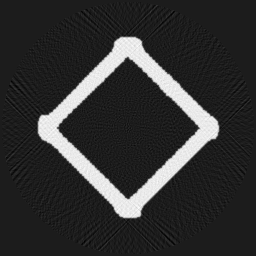

Saved slice visualization to slice_preview.png (slice_index=128, axis=0, image_size=256x256, source_shape=(256, 256, 256), source_dtype=uint8).


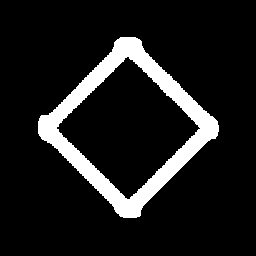

'Saved slice visualization to slice_preview.png (slice_index=128, axis=0, image_size=256x256, source_shape=(256, 256, 256), source_dtype=uint8).'

In [16]:
# Visualization now goes through the visualize_slice MCP tool (writes a PNG, then shows it)
show_slice(nm)                 # raw unitcell volume — middle slice
show_slice("out_mask.npy")     # the segmented mask

# Optional: pick a slice / axis / output filename
# show_slice(nm, slice_index=64, axis=1, out_png="raw_axis1_64.png")

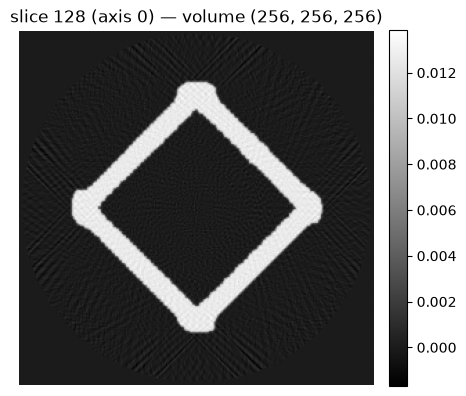

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(256, 256), dtype=float32)

In [17]:
view_npy(nm)   

Saved segmentation to out_mask.npy (shape=(256, 256, 256), dtype=uint8, threshold=0.007, foreground=712688/16777216 voxels, 4.25%).
max raw: 0.015257691964507103
min raw: -0.003128750016912818
max mask: 1
min mask: 0
avg raw: 0.0005390668520703912
only 0/1?  [0, 1]


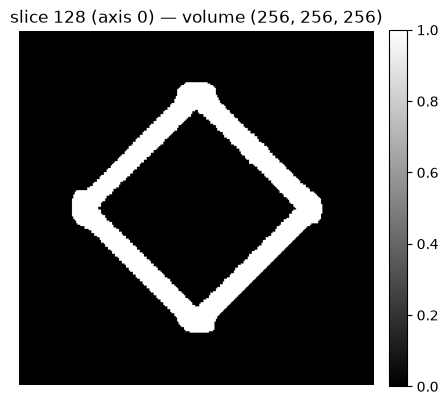

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256), dtype=uint8)

In [19]:

raw = np.load(nm)
print(m.segment_ct_dataset(nm, "out_mask.npy", 0.007))
mask = np.load("out_mask.npy")
print(f"max raw: {np.max(raw)}")
print(f"min raw: {np.min(raw)}")
print(f"max mask: {np.max(mask)}")
print(f"min mask: {np.min(mask)}")
print(f"avg raw: {np.average(raw)}")
print("only 0/1? ", np.unique(mask).tolist())              # -> [0, 1]


view_npy("out_mask.npy")   